In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from tqdm import tqdm

torch.backends.cudnn.benchmark = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using Device:", device)

Using Device: cuda


# CELL 2 — Dataset Paths + Hyperparameters

In [2]:
train_dir = "/kaggle/input/datasets/shamimulislamsunny/isic-2024-dataset/hair_removed/train"
test_dir  = "/kaggle/input/datasets/shamimulislamsunny/isic-2024-dataset/hair_removed/test"

IMG_SIZE   = 260
BATCH_SIZE = 32
EPOCHS     = 20
LR         = 1e-4

# CELL 3 — Transforms

In [3]:
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

test_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# CELL 4 — Train + Validation Dataset

In [4]:
full_train_ds = datasets.ImageFolder(train_dir, transform=train_tf)

class_names = full_train_ds.classes

train_size = int(0.8 * len(full_train_ds))
val_size   = len(full_train_ds) - train_size

train_ds, val_ds = random_split(full_train_ds, [train_size, val_size])

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

print("Train Images      :", len(train_ds))
print("Validation Images :", len(val_ds))
print("Classes           :", class_names)

Train Images      : 257998
Validation Images : 64500
Classes           : ['benign', 'malignant']


# CELL 5 — Test Dataset

In [5]:
test_ds = datasets.ImageFolder(test_dir, transform=test_tf)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

print("Test Images :", len(test_ds))

Test Images : 80212


# CELL 6 — EfficientNet-B2 Model

In [6]:
model = models.efficientnet_b2(
    weights=models.EfficientNet_B2_Weights.IMAGENET1K_V1
)

model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    2
)

model     = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=LR)
scaler    = torch.cuda.amp.GradScaler()

Downloading: "https://download.pytorch.org/models/efficientnet_b2_rwightman-c35c1473.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b2_rwightman-c35c1473.pth


100%|██████████| 35.2M/35.2M [00:00<00:00, 169MB/s]
/tmp/ipykernel_22/2335159843.py:13: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = torch.cuda.amp.GradScaler()


# CELL 7 — Training Function (Train + Val + Test per Epoch)

In [7]:
# ✅ FIX: history only tracks train and val — NOT test
history = {
    "loss"          : [],
    "accuracy"      : [],
    "precision"     : [],
    "recall"        : [],
    "f1"            : [],

    "val_loss"      : [],
    "val_accuracy"  : [],
    "val_precision" : [],
    "val_recall"    : [],
    "val_f1"        : [],
}

def evaluate(model, loader):
    """Runs inference on a loader, returns loss + all metrics."""
    model.eval()

    running_loss = 0
    all_preds    = []
    all_labels   = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)

            out  = model(x)
            loss = criterion(out, y)

            running_loss += loss.item()

            _, pred = torch.max(out, 1)
            all_preds.extend(pred.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    avg_loss = running_loss / len(loader)
    acc      = accuracy_score (all_labels, all_preds)
    pre      = precision_score(all_labels, all_preds, zero_division=0)
    rec      = recall_score   (all_labels, all_preds, zero_division=0)
    f1       = f1_score       (all_labels, all_preds, zero_division=0)

    return avg_loss, acc, pre, rec, f1


# ✅ FIX: train_model no longer takes test_loader or evaluates test inside
def train_model(model, train_loader, val_loader, optimizer, epochs):

    for ep in range(epochs):

        # ================= TRAIN =================
        model.train()

        running_loss = 0
        train_preds  = []
        train_labels = []

        loop = tqdm(train_loader)

        for x, y in loop:

            x = x.to(device)
            y = y.to(device)

            optimizer.zero_grad()

            with torch.cuda.amp.autocast():
                out  = model(x)
                loss = criterion(out, y)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item()

            _, pred = torch.max(out, 1)
            train_preds.extend(pred.cpu().numpy())
            train_labels.extend(y.cpu().numpy())

            loop.set_description(f"Epoch {ep+1}/{epochs}")
            loop.set_postfix(loss=loss.item())

        # ===== TRAIN METRICS =====
        train_loss = running_loss / len(train_loader)
        train_acc  = accuracy_score (train_labels, train_preds)
        train_pre  = precision_score(train_labels, train_preds, zero_division=0)
        train_rec  = recall_score   (train_labels, train_preds, zero_division=0)
        train_f1   = f1_score       (train_labels, train_preds, zero_division=0)

        history["loss"]     .append(train_loss)
        history["accuracy"] .append(train_acc)
        history["precision"].append(train_pre)
        history["recall"]   .append(train_rec)
        history["f1"]       .append(train_f1)

        # ================= VALIDATION =================
        val_loss, val_acc, val_pre, val_rec, val_f1 = evaluate(model, val_loader)

        history["val_loss"]     .append(val_loss)
        history["val_accuracy"] .append(val_acc)
        history["val_precision"].append(val_pre)
        history["val_recall"]   .append(val_rec)
        history["val_f1"]       .append(val_f1)

        # ================= PRINT =================
        print(f"\nEpoch {ep+1}/{epochs}")
        print(f"  Train — Loss: {train_loss:.4f} | Acc: {train_acc:.4f} | Pre: {train_pre:.4f} | Rec: {train_rec:.4f} | F1: {train_f1:.4f}")
        print(f"  Val   — Loss: {val_loss:.4f} | Acc: {val_acc:.4f} | Pre: {val_pre:.4f} | Rec: {val_rec:.4f} | F1: {val_f1:.4f}")

# CELL 8 — Run Training

In [8]:
# Freeze Feature Extractor
for param in model.features.parameters():
    param.requires_grad = False

print("\n===== TRAINING STARTED =====")

# ✅ FIX: pass only train_loader and val_loader — no test_loader
train_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    EPOCHS
)

torch.save(model.state_dict(), "efficientnet_b2_base_model.pth")

print("\n✅ Training Complete")
print("✅ Model Saved")


===== TRAINING STARTED =====


  0%|          | 0/8063 [00:00<?, ?it/s]/tmp/ipykernel_22/840661590.py:68: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 1/20: 100%|██████████| 8063/8063 [12:49<00:00, 10.47it/s, loss=0.00993]



Epoch 1/20
  Train — Loss: 0.0457 | Acc: 0.9930 | Pre: 0.0448 | Rec: 0.0056 | F1: 0.0099
  Val   — Loss: 0.0362 | Acc: 0.9942 | Pre: 0.3273 | Rec: 0.0508 | F1: 0.0880


  0%|          | 0/8063 [00:00<?, ?it/s]/tmp/ipykernel_22/840661590.py:68: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 2/20: 100%|██████████| 8063/8063 [09:20<00:00, 14.38it/s, loss=0.00623]



Epoch 2/20
  Train — Loss: 0.0324 | Acc: 0.9938 | Pre: 0.5775 | Rec: 0.0509 | F1: 0.0936
  Val   — Loss: 0.0307 | Acc: 0.9947 | Pre: 0.5591 | Rec: 0.1469 | F1: 0.2327


...


Epoch 18/20
  Train — Loss: 0.0256 | Acc: 0.9945 | Pre: 0.7637 | Rec: 0.1645 | F1: 0.2707
  Val   — Loss: 0.0207 | Acc: 0.9952 | Pre: 0.8133 | Rec: 0.1723 | F1: 0.2844


  0%|          | 0/8063 [00:00<?, ?it/s]/tmp/ipykernel_22/840661590.py:68: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 19/20: 100%|██████████| 8063/8063 [09:26<00:00, 14.23it/s, loss=0.00139]



Epoch 19/20
  Train — Loss: 0.0253 | Acc: 0.9944 | Pre: 0.7500 | Rec: 0.1527 | F1: 0.2537
  Val   — Loss: 0.0206 | Acc: 0.9953 | Pre: 0.7700 | Rec: 0.2175 | F1: 0.3392


  0%|          | 0/8063 [00:00<?, ?it/s]/tmp/ipykernel_22/840661590.py:68: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 20/20: 100%|██████████| 8063/8063 [09:22<00:00, 14.33it/s, loss=0.00663]



Epoch 20/20
  Train — Loss: 0.0252 | Acc: 0.9944 | Pre: 0.7640 | Rec: 0.1608 | F1: 0.2656
  Val   — Loss: 0.0208 | Acc: 0.9954 | Pre: 0.8391 | Rec: 0.2062 | F1: 0.3311

✅ Training Complete
✅ Model Saved


# CELL 9 — Load Trained Model

In [9]:
model = models.efficientnet_b2(weights=None)

model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    2
)

model.load_state_dict(
    torch.load("efficientnet_b2_base_model.pth", map_location=device)
)

model = model.to(device)
model.eval()

print("✅ Model Loaded")

✅ Model Loaded


# CELL 10 — Final Predictions on Test Data

In [10]:
# ✅ FIX: Test evaluation happens ONCE here — after training is fully done
print("Predicting on test data...")

y_true         = []
y_pred_classes = []
y_probs        = []

with torch.no_grad():
    for x, y in tqdm(test_loader):

        x = x.to(device)

        out   = model(x)
        probs = torch.softmax(out, dim=1)[:, 1]
        _, preds = torch.max(out, 1)

        y_true.extend(y.numpy())
        y_pred_classes.extend(preds.cpu().numpy())
        y_probs.extend(probs.cpu().numpy())

y_true         = np.array(y_true)
y_pred_classes = np.array(y_pred_classes)
y_probs        = np.array(y_probs)

print("✅ Prediction Complete")

Predicting on test data...


100%|██████████| 2507/2507 [04:04<00:00, 10.24it/s]

✅ Prediction Complete


# CELL 11 — Classification Report

In [11]:
print("\n" + "="*30)
print("     CLASSIFICATION REPORT")
print("="*30)
print(classification_report(y_true, y_pred_classes, target_names=class_names))
print("="*30)


     CLASSIFICATION REPORT
              precision    recall  f1-score   support

      benign       1.00      1.00      1.00     80133
   malignant       0.00      0.00      0.00        79

    accuracy                           1.00     80212
   macro avg       0.50      0.50      0.50     80212
weighted avg       1.00      1.00      1.00     80212



#  CELL 12 — Performance Metrics

In [12]:
acc = accuracy_score (y_true, y_pred_classes)
pre = precision_score(y_true, y_pred_classes, zero_division=0)
rec = recall_score   (y_true, y_pred_classes, zero_division=0)
f1  = f1_score       (y_true, y_pred_classes, zero_division=0)

print("\n===== FINAL PERFORMANCE METRICS =====")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {pre:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1-Score  : {f1:.4f}")


===== FINAL PERFORMANCE METRICS =====
Accuracy  : 0.9989
Precision : 0.0000
Recall    : 0.0000
F1-Score  : 0.0000


# CELL 13 — Train vs Val vs Test — Loss & Accuracy

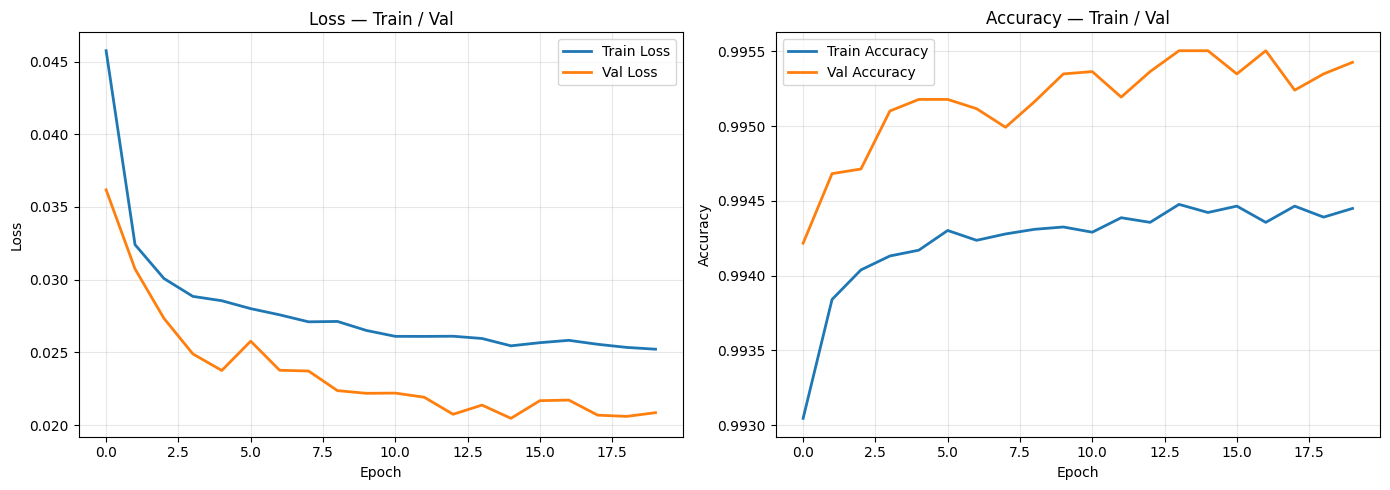

In [13]:
plt.figure(figsize=(14, 5))

# ===== LOSS =====
plt.subplot(1, 2, 1)
plt.plot(history["loss"],     label="Train Loss", lw=2)
plt.plot(history["val_loss"], label="Val Loss",   lw=2)
plt.title("Loss — Train / Val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)

# ===== ACCURACY =====
plt.subplot(1, 2, 2)
plt.plot(history["accuracy"],     label="Train Accuracy", lw=2)
plt.plot(history["val_accuracy"], label="Val Accuracy",   lw=2)
plt.title("Accuracy — Train / Val")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# CELL 14 — Train vs Val vs Test — Precision, Recall, F1

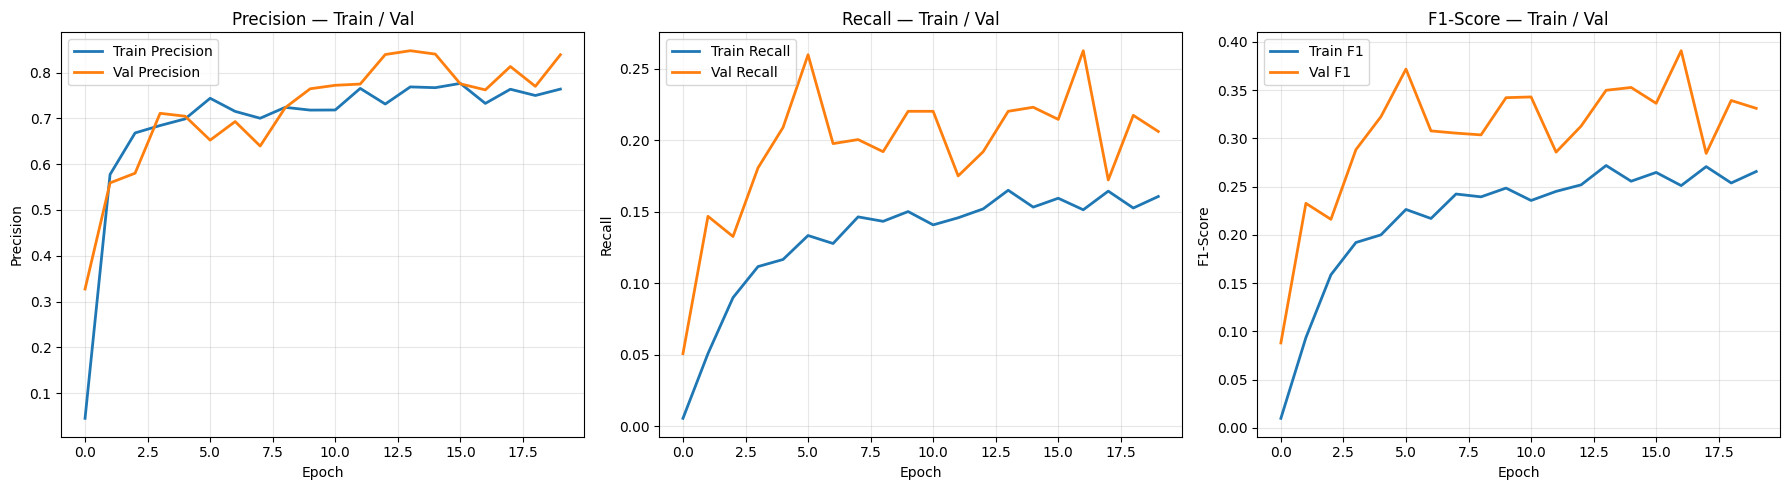

In [14]:
plt.figure(figsize=(18, 5))

# ===== PRECISION =====
plt.subplot(1, 3, 1)
plt.plot(history["precision"],     label="Train Precision", lw=2)
plt.plot(history["val_precision"], label="Val Precision",   lw=2)
plt.title("Precision — Train / Val")
plt.xlabel("Epoch")
plt.ylabel("Precision")
plt.legend()
plt.grid(True, alpha=0.3)

# ===== RECALL =====
plt.subplot(1, 3, 2)
plt.plot(history["recall"],     label="Train Recall", lw=2)
plt.plot(history["val_recall"], label="Val Recall",   lw=2)
plt.title("Recall — Train / Val")
plt.xlabel("Epoch")
plt.ylabel("Recall")
plt.legend()
plt.grid(True, alpha=0.3)

# ===== F1 =====
plt.subplot(1, 3, 3)
plt.plot(history["f1"],     label="Train F1", lw=2)
plt.plot(history["val_f1"], label="Val F1",   lw=2)
plt.title("F1-Score — Train / Val")
plt.xlabel("Epoch")
plt.ylabel("F1-Score")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# CELL 15 — Confusion Matrix

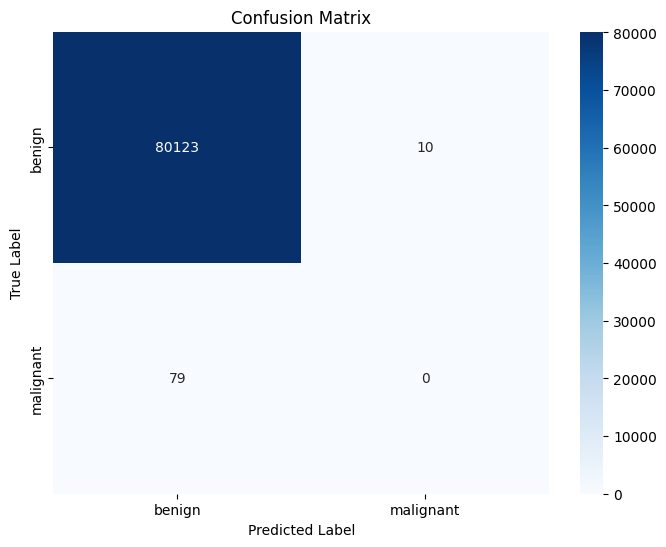

In [15]:
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title("Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()

# CELL 16 — ROC Curve

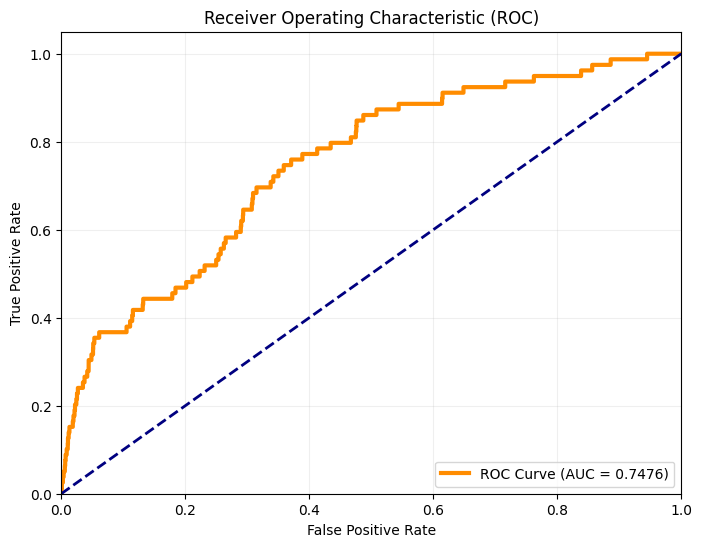

In [16]:
fpr, tpr, _ = roc_curve(y_true, y_probs)
roc_auc     = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=3,
         label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC)")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.2)
plt.show()

#  CELL 17 — Final Summary

In [17]:
print("\n===== FINAL ANALYSIS SUMMARY =====")
print(f"Accuracy                : {acc:.4f}")
print(f"Precision               : {pre:.4f}")
print(f"Recall                  : {rec:.4f}")
print(f"F1-Score                : {f1:.4f}")
print(f"ROC-AUC Score           : {roc_auc:.4f}")
print(f"Best Val Accuracy       : {max(history['val_accuracy']):.4f}")
print(f"Best Val F1             : {max(history['val_f1']):.4f}")


===== FINAL ANALYSIS SUMMARY =====
Accuracy                : 0.9989
Precision               : 0.0000
Recall                  : 0.0000
F1-Score                : 0.0000
ROC-AUC Score           : 0.7476
Best Val Accuracy       : 0.9955
Best Val F1             : 0.3908
